<>:71: SyntaxWarning: invalid escape sequence '\|'
<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\|'
<>:79: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1679295/2847309850.py:71: SyntaxWarning: invalid escape sequence '\|'
  axes[0].set_ylabel('$(\|A\| - \|Av^k\|)/\|A\|$')
/tmp/ipykernel_1679295/2847309850.py:79: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_ylabel('$\min\{|a_k|^2\ |\ 0\leq k \leq n\}$')


norm(A) = 53.479925672889756
Step  9999. Est: 53.28, (step with size -3.30e-04)
   Reached norm with relative error 0.37%
Step  9999. Est: 53.06, (step with size -2.07e-03)
   Reached norm with relative error 0.79%
Step  9999. Est: 53.10, (step with size -9.82e-04)
   Reached norm with relative error 0.71%
Step  9999. Est: 53.26, (step with size -2.49e-04)
   Reached norm with relative error 0.41%
Step  9999. Est: 53.36, (step with size 1.51e-03)
   Reached norm with relative error 0.23%
Step  9999. Est: 53.42, (step with size 4.84e-04)
   Reached norm with relative error 0.11%
Step  9999. Est: 53.00, (step with size -4.37e-04)
   Reached norm with relative error 0.89%
Step  9999. Est: 53.37, (step with size 2.01e-04)
   Reached norm with relative error 0.20%
Step  9999. Est: 53.21, (step with size 2.04e-03)
   Reached norm with relative error 0.51%
Step  9999. Est: 53.17, (step with size 1.24e-03)
   Reached norm with relative error 0.58%
Step  9999. Est: 53.02, (step with size 9.63e-

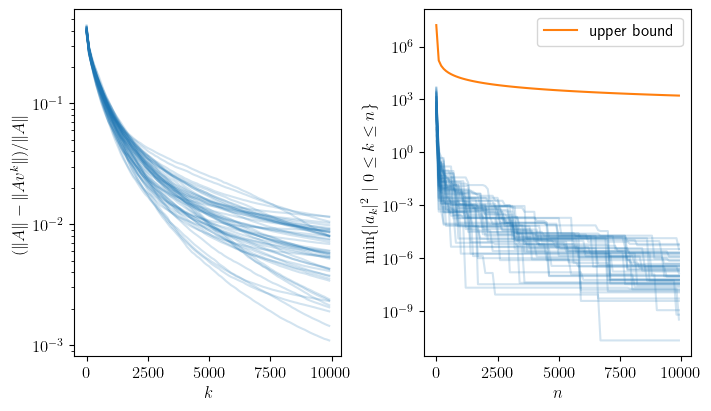

In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 12
})

def randnexample(m,n,step):
    # Make 50 runs with a randn matrix of size m by n with 20*n
    # shows results and exports plot (with step as subsampling to save memory)
    
    # matrix
    A = np.random.randn(m,n)
    # and its norm
    normA = np.linalg.norm(A,ord=2)
    
    print(f'norm(A) = {normA}')
    
    
    maxiter = 20*n  # number of iterations
    check = round(maxiter/1)    # how often do we give output
    
    
    
    numRuns = 50
    color='C0'
    alpha = 0.2
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,4), constrained_layout=True)
    #fig.tight_layout() # Or equivalently,  "plt.tight_layout()"
    
    for run in range(numRuns):
        # initialize with random unit vector
        v = np.random.randn(n)
        v /= np.linalg.norm(v)
        Av = A@v
        normAv = np.linalg.norm(Av)
        
        # list of estimates
        nA = []
        
        # list of as
        a_s = []
        
        nA.append(normAv)
        nostep = 0
        for i in range(maxiter):
            # sample x orthogonal to v with unit norm
            x = np.random.randn(n)
            x -= np.dot(x,v)*v
            x /= np.linalg.norm(x)
            Ax = A@x
            normAx = np.linalg.norm(Ax)
            vOld = v.copy()
            a = np.dot(Ax,Av)
            b = normAx**2 - normAv**2
            tau = np.sign(a)*(b/(2*np.abs(a)) + np.sqrt(b**2/(4*a**2)+1))
            v += tau*x
            v /= np.linalg.norm(v)
            Av = A@v
            normAv = np.linalg.norm(Av)
            nA.append(normAv)
            a_s.append(a)
            
        print(f'Step {i: 5d}. Est: {nA[-1]:2.2f}, (step with size {tau:2.2e})')
            
        print(f'   Reached norm with relative error {100*(normA-nA[-1])/normA:2.2f}%')
        
        axes[0].semilogy(np.arange(1,maxiter+1)[::step],(normA - nA[:-1:step])/normA, color=color, alpha=alpha)
        axes[0].set_xlabel('$k$')
        axes[0].set_ylabel('$(\|A\| - \|Av^k\|)/\|A\|$')

        a_s = np.array(a_s)
        a2min = np.minimum.accumulate(a_s[:-1]**2)
        #axes[1].semilogy(np.arange(1,maxiter+1)[::step],np.abs(a_s[:-1:step]), color=color, alpha=alpha)
        axes[1].semilogy(np.arange(1,maxiter)[::step],a2min[::step], color=color, alpha=alpha)
    axes[1].semilogy(np.arange(1,maxiter+1)[::step],2*normA**4/np.arange(1,maxiter+1)[::step],label='upper bound',color='C1')
    axes[1].set_xlabel('$n$')
    axes[1].set_ylabel('$\min\{|a_k|^2\ |\ 0\leq k \leq n\}$')
    axes[1].legend()
        
    
    plt.savefig(f'../figures/experiment3_{m}x{n}.pdf')
    plt.show()

randnexample(1000,500,100)